In [2]:
# Enable automatic reloading of modules before executing code
%load_ext autoreload
%autoreload 2

In [3]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
import seaborn as sns

import matplotlib.patches as patches
import matplotlib.colors as mcolors

In [4]:
import utils as ut

# Hold-Out Accuracy

In [43]:
df_plt = pd.read_csv("data/dataframes-plotting-ms/accuracy-over-ndim.csv")
with open("data/dataframes-plotting-ms/accuracy-over-ndim-legend.pkl", "rb") as f:
    legend_dict = pickle.load(f)

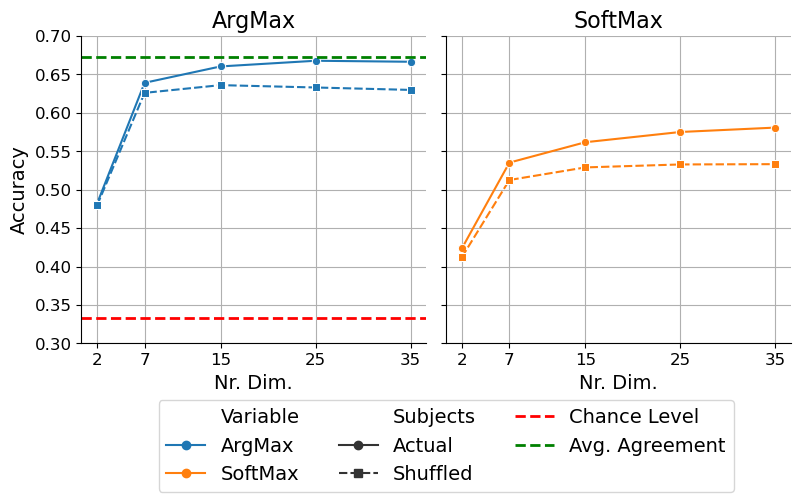

In [54]:
df_plt2 = df_plt.groupby(["md", "Subjects", "Nr. Dim.", "Variable"])["Accuracy"].max().reset_index()

g = sns.relplot(
    data=df_plt2, 
    x='Nr. Dim.', y='Accuracy', style = "Subjects", col="Variable", height=4,
    hue="Variable", marker="o", aspect=1, kind="line", markers=marker_styles, legend=False
)
g.set_titles("{col_name}")
g = plot_holdout_accuracy(g, legend_dict)

g.savefig("documents/writeup/figures-plotting/accuracy-benefit-over-dimensions.pdf")

# Split-Half Reliabilities

In [5]:
df_splithalf_summary_long = pd.read_csv("data/dataframes-plotting-ms/splithalf-reliabilities-1.csv")
df_corrs = pd.read_csv("data/dataframes-plotting-ms/splithalf-reliabilities-2.csv")

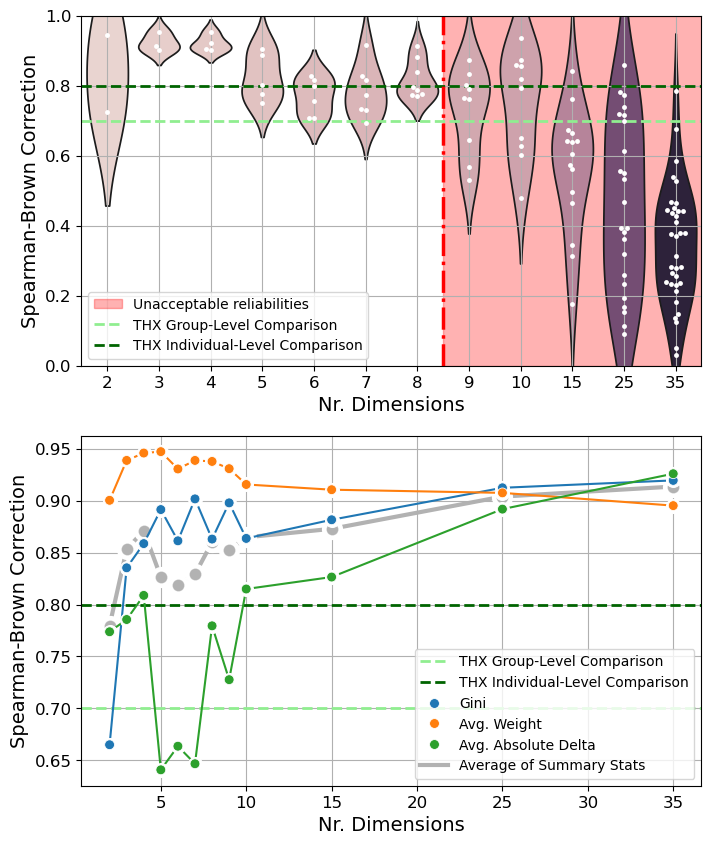

In [7]:
f, axes = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))
f, axes = ut.reliabilities_over_dimensionalities(df_splithalf_summary_long, df_corrs, f, axes)

f.savefig("documents/writeup/figures-plotting/splithalf-reliability.pdf")

# D35

## Correlations Demographics & Questionnaires

In [3]:
df_qs_num_hm = pd.read_csv("data/dataframes-plotting-ms/qs-dems-correlations.csv")

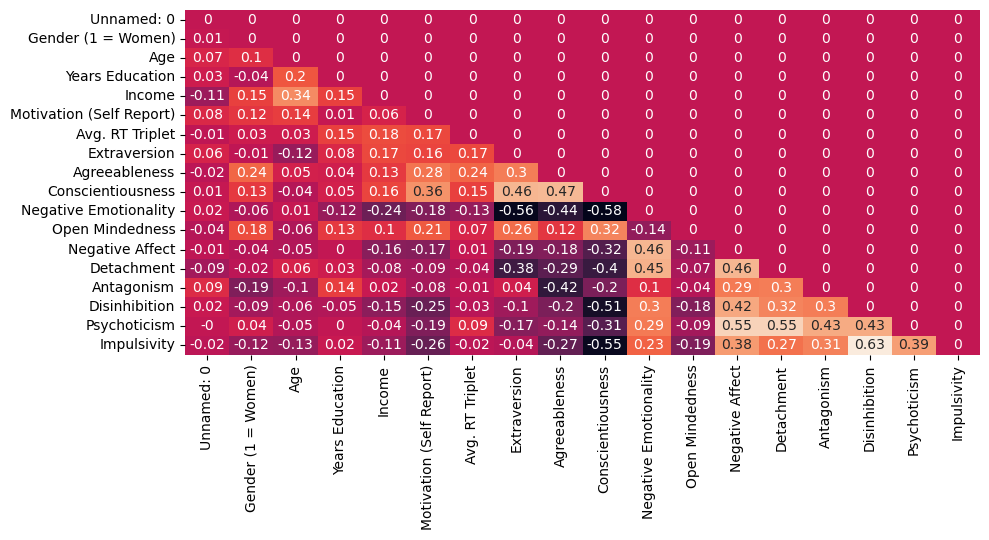

In [4]:
f, ax = plt.subplots(1, figsize=(10, 5.5))

df_hm = pd.DataFrame(np.tril(np.round(np.corrcoef(df_qs_num_hm.transpose()), 2), k=-1))
df_hm.columns = df_qs_num_hm.columns
df_hm.index = df_qs_num_hm.columns
sns.heatmap(df_hm, annot=True, ax=ax, cbar=False)

_ = plt.tight_layout()
f.savefig("documents/writeup/figures-plotting/heatmap-no-dimensional-weights.pdf")

## Correlations Summary Stats

In [28]:
df_corr_weight = pd.read_csv("data/dataframes-plotting-ms/avgweight-cors-d35.csv")
df_corr_weight_change = pd.read_csv("data/dataframes-plotting-ms/weightconsistency-cors-d35.csv")
df_corr_gini = pd.read_csv("data/dataframes-plotting-ms/gini-cors-d35.csv")

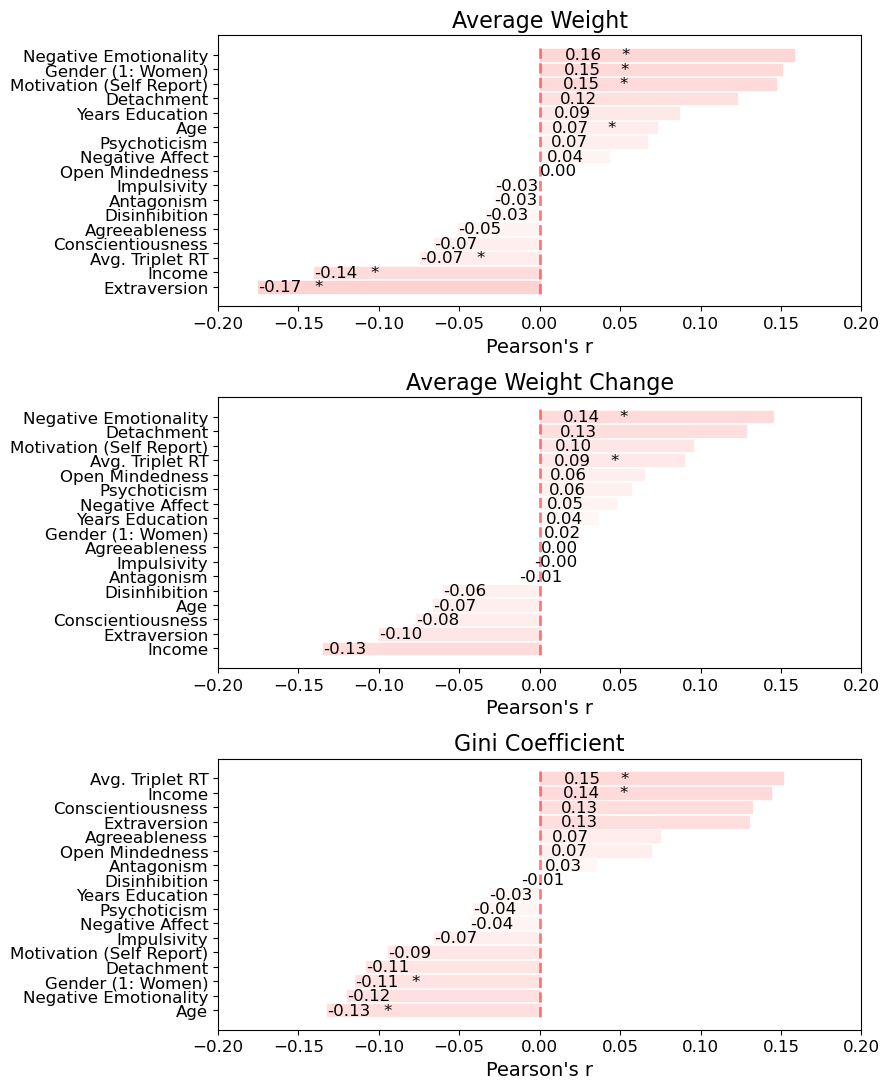

In [29]:
f_all, axes = plt.subplots(nrows=3, figsize=(9, 11))
ut.barplot_cols(df_corr_weight.query("var not in ['idx']").copy(), "Average Weight", f_all, axes[0])
ut.barplot_cols(df_corr_weight_change.query("var not in ['idx']").copy(), "Average Weight Change", f_all, axes[1])
ut.barplot_cols(df_corr_gini.query("var not in ['idx']").copy(), "Gini Coefficient", f_all, axes[2])
plt.tight_layout()
f_all.savefig("documents/writeup/figures-plotting/summarystats-correlations-35d.pdf")

# All Dimensionalities

In [30]:
df_plt = pd.read_csv("data/dataframes-plotting-ms/correlations-alldims.csv")

/ictstr01/home/hcai/mirko.thalmann/semantic-representations-ID/utils.py:3666: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(wrapped_labels)
/ictstr01/home/hcai/mirko.thalmann/semantic-representations-ID/utils.py:3666: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(wrapped_labels)
/ictstr01/home/hcai/mirko.thalmann/semantic-representations-ID/utils.py:3666: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(wrapped_labels)


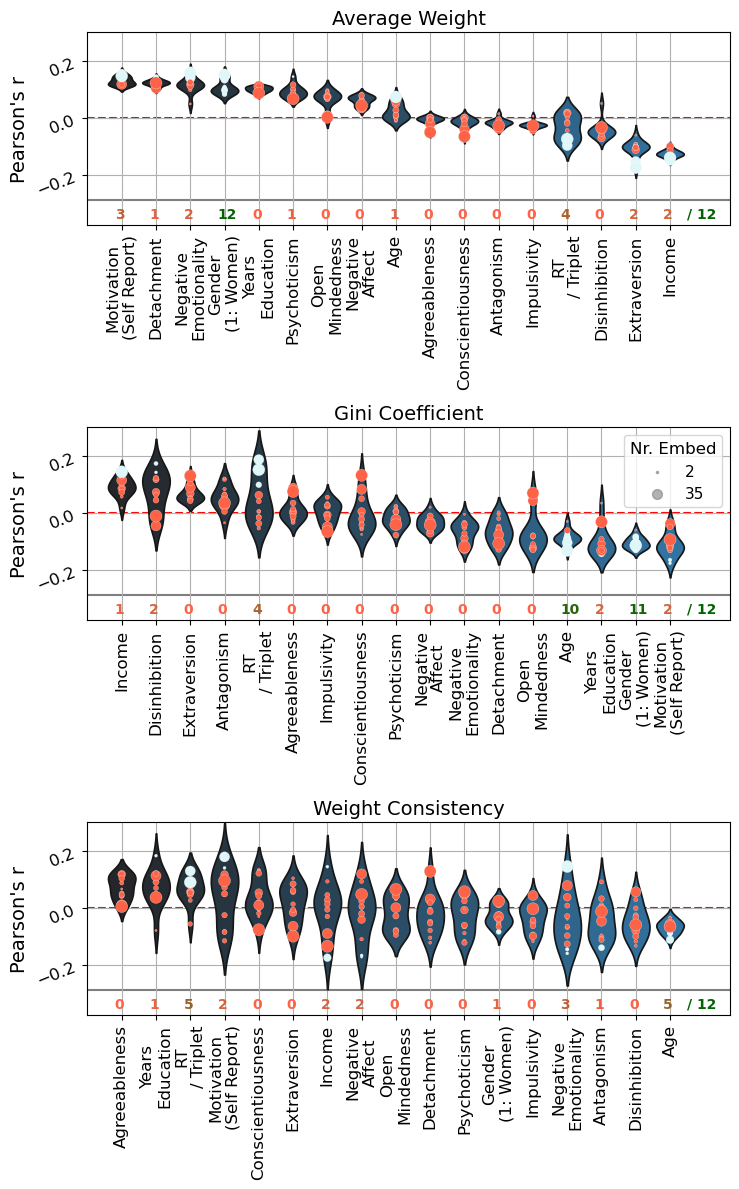

In [31]:
f, axes = plt.subplots(3, figsize=(7.5, 12))
f, axes = ut.plot_cors_sumstat_violin(df_plt, f, axes)

plt.tight_layout()
f.savefig("documents/writeup/figures-plotting/qs-dems-correlations.pdf")

# Hyperparameter Search

In [83]:
tbl_plt2 = pd.read_pickle("highdim-plot-data.pkl")

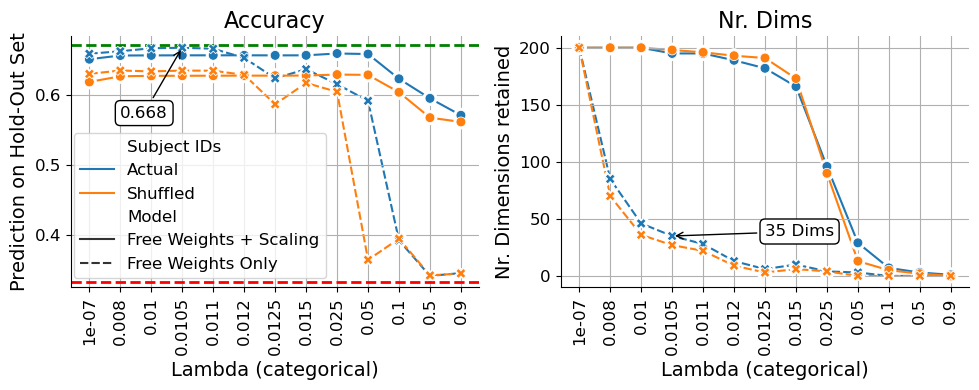

In [87]:
g = sns.FacetGrid(data=tbl_plt2, col="variable", col_wrap=2, sharey=False, height=4, aspect=1.25)
g = ut.plot_hyp_search(g, tbl_plt2)
g.savefig("documents/writeup/figures-plotting/accuracy-benefit.pdf")

# Mappability

In [5]:
df_cors = pd.read_pickle("data/dataframes-plotting-ms/mappability.pkl")

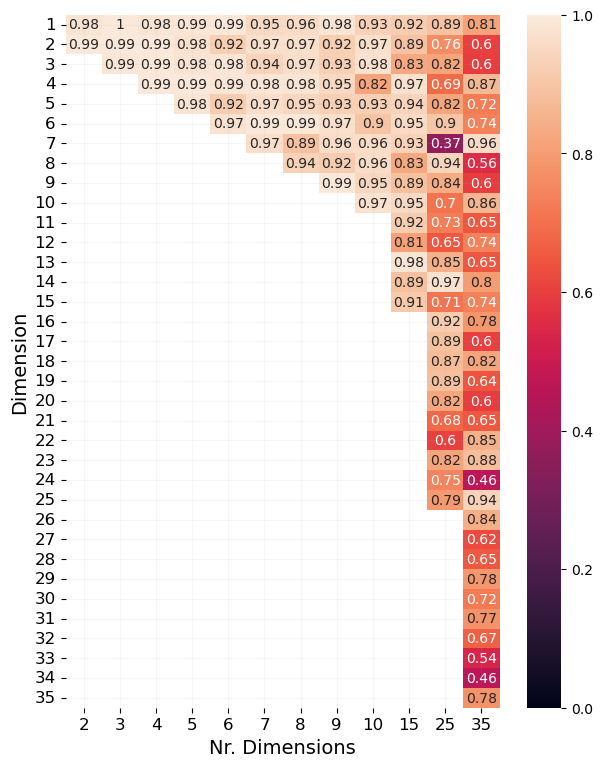

In [25]:
range_dims = [i for i in range(2, 11)] + [15, 25, 35]

f, ax = plt.subplots(1, figsize=(7, 9))

df_cors_mappable = df_cors[[d for d in range_dims if d < 45]].loc[1:35,:]
sns.heatmap(df_cors_mappable, annot=True, mask=df_cors_mappable.isna(), vmin=0, vmax=1, ax=ax)
ax.set_title(ax.get_title(), fontsize=16)
ax.set_xlabel(ax.get_xlabel(), fontsize=14)
ax.set_ylabel("Dimension", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.tick_params(axis="y", labelrotation=0, labelsize=12)
plt.grid(True, alpha=.1)
_ = ax.set_xlabel("Nr. Dimensions")

f.savefig("documents/writeup/figures-plotting/mappability.pdf")

# Model Deltas

In [96]:
df_triplets_study = pd.read_csv("data/dataframes-plotting-ms/triplets_study.csv")
df_items_delta = pd.read_csv("data/dataframes-plotting-ms/triplets_all.csv")

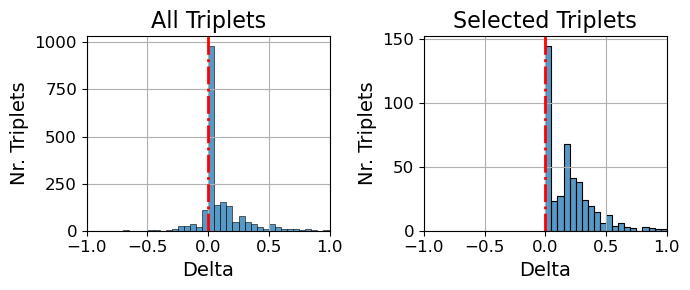

In [97]:
f, axes = plt.subplots(1, 2, figsize=(7, 3))

sns.histplot(data=df_triplets_study.rename(columns={'delta': 'Delta'}), x="Delta", binwidth=.05, ax = axes[1])
sns.histplot(data=df_items_delta, x="delta", binwidth=.05, ax = axes[0])
axes[0].set_title("All Triplets")
axes[1].set_title("Selected Triplets")

for ax in axes:
    ax.set_title(ax.get_title(), fontsize=16)
    ax.set_xlabel("Delta", fontsize=14)
    ax.set_ylabel("Nr. Triplets", fontsize=14)
    ax.axvline(x=0, color="red", linestyle="-.", linewidth=2)
    ax.set_xlim((-1, 1))
    ax.tick_params(axis='both', labelsize=12)
    ax.grid(True)

plt.tight_layout()
f.savefig("documents/writeup/figures-plotting/model-delta-histograms.pdf")

# Predict Dimensional Weights Using Free Text Responses on Work and General Interests

In [4]:
df_compare = pd.read_pickle("data/dataframes-plotting-ms/text-weights-mapping.pkl")

In [5]:
df_compare

,diff,diff_heuristic
ndim_pca,,
10,16.290922,14.30877
30,16.268886,14.30877
50,16.266267,14.30877
70,16.247758,14.30877
90,16.291559,14.30877


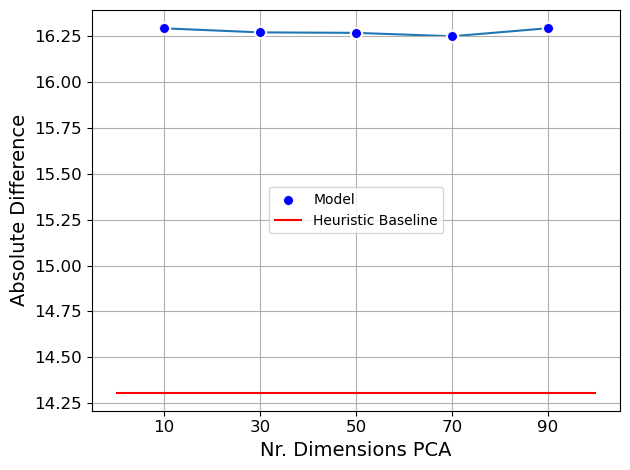

In [8]:
fig, ax = plt.subplots(1)

sns.lineplot(data=df_compare, x="ndim_pca", y="diff", ax=ax, zorder=1)
sns.scatterplot(data=df_compare, x="ndim_pca", y="diff", ax=ax, color='white', s=80, zorder=2)
sns.scatterplot(
    data=df_compare,
    x="ndim_pca",
    y="diff",
    ax=ax,
    color='blue',
    s=50,
    zorder=3,
    label="Model"
)
ax.set_xlabel("Nr. Dimensions PCA", fontsize=14)
ax.set_ylabel("Absolute Difference", fontsize=14)
ax.set_xticks(ticks=[10, 30, 50, 70, 90])

ax.set_title(ax.get_title(), fontsize=16)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True)
ax.hlines(y=df_compare.iloc[0, 1], xmin=0, xmax=100, color="red", label="Heuristic Baseline")

_ = ax.legend(loc="center")

plt.tight_layout()
fig.savefig("documents/writeup/figures-plotting/diffs-predict-model-weights-from-interests.pdf")

# Embedding Dimensions

In [10]:
ndim = 35

df_embeddings_full = pd.read_pickle(f"data/dataframes-plotting-ms/object-embeddings-d-{ndim}.pkl")
ndim_range = np.array(np.ceil(np.linspace(0, ndim, int(np.ceil(ndim / 12)) + 1)), dtype=int)

import re
import os
from functools import partial
from PIL import Image

l_concepts = os.listdir("data/images/")
l_m = [re.match("^[a-z]", l_concepts[i]) for i in range(0, len(l_concepts))]
l_filter = [l_m[i] != None for i in range(0, len(l_concepts))]
l_concepts_filtered = [value for value, flag in zip(l_concepts, l_filter) if flag]
f_partial = partial(ut.extract_image, l_concepts_filtered)


df_embeddings_full.columns = df_embeddings_full.columns.map(str)
cols_importance = df_embeddings_full.loc[:,[str(i) for i in range(int(ndim_range[-1]))]].sum(axis=0).sort_values(ascending=False).index
df_embeddings_full = df_embeddings_full[["image_id"] + [str(i) for i in cols_importance]]

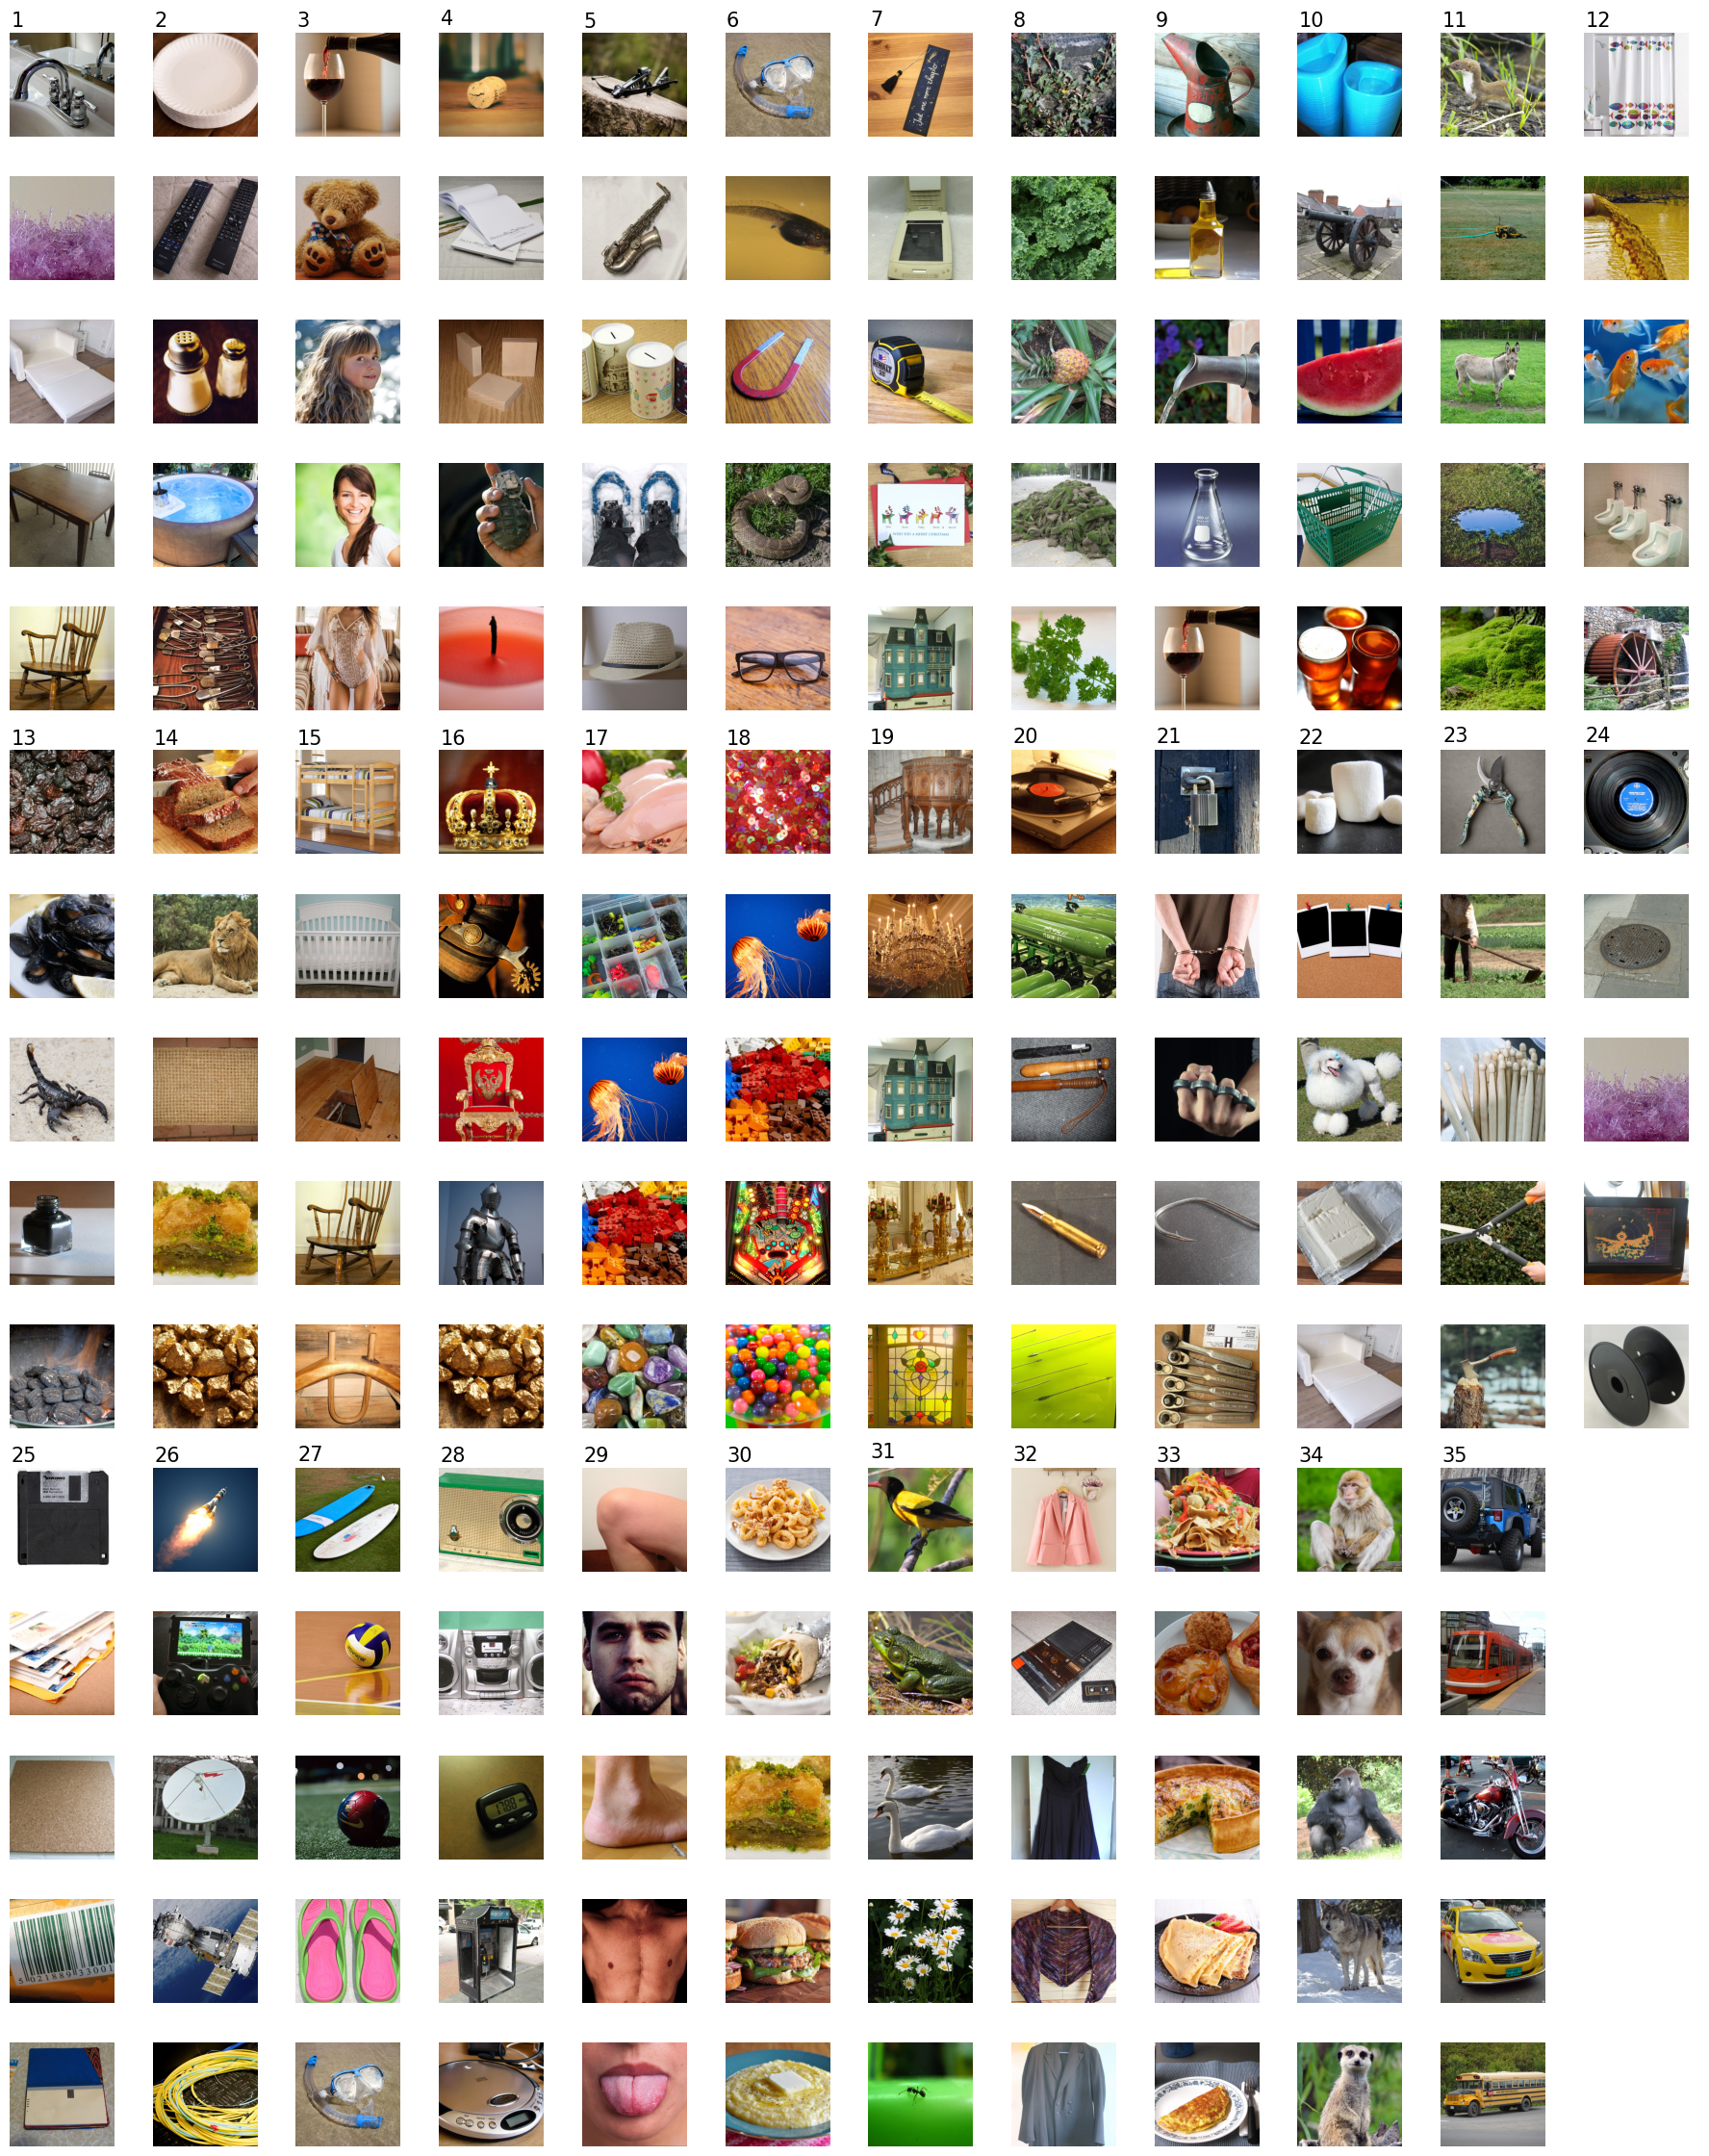

In [11]:
# Normalize correlation to [0, 1] for size scaling
n_images_plot = 5

f, axes = plt.subplots(
    n_images_plot * (len(ndim_range) - 1), ndim_range[1], 
    figsize=(ndim_range[1] * 1.5, n_images_plot * (len(ndim_range) - 1) * 1.5)
)

for idx, current_dim in enumerate(cols_importance):

    lot_coded = df_embeddings_full[["image_id", current_dim]].sort_values(current_dim, ascending=False).reset_index(drop=True)
    
    l_ids_lot_coded = lot_coded.loc[0:(n_images_plot-1), "image_id"]
    paths_lot_coded = list(map(f_partial, l_ids_lot_coded))

    col = idx % ndim_range[1]
    
    for j in range(n_images_plot):
        # plot the images
        rowadd = np.floor(idx / ndim_range[1])
        img = Image.open(paths_lot_coded[j])
        axes[j + int(rowadd * n_images_plot), col].imshow(img)
        axes[j + int(rowadd * n_images_plot), col].axis("off")

        # add the dimension number just before the first image of that dimension
        if j % n_images_plot == 0:
            axes[j + int(rowadd * n_images_plot), col].text(x=10, y=-50, s=str(idx+1), fontsize=15)

for current_dim in range(ndim_range[-1], int(ndim_range[1] * (len(ndim_range) - 1))):
    col = current_dim % ndim_range[1]
    for j in range(n_images_plot):
        rowadd = np.floor(current_dim / ndim_range[1])
        axes[j + int(rowadd * n_images_plot), col].axis("off")

_ = plt.tight_layout()

plt.savefig(f"documents/writeup/embeddings-{ndim}d-top-{int(n_images_plot)}-objects.pdf")